In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.decomposition import PCA
import seaborn as sns

In [18]:
# COLAB SETUP - (generated by Claude). Allows different members of the project to run the code in google colab.
# This code snippet copies our project's github repo to the google colab environment.
import os, sys
if 'google.colab' in sys.modules:
    os.chdir('/content/')
    if os.path.exists('data-driven-engineering'):
        !rm -rf data-driven-engineering
    !git clone https://github.com/miirage-exe/data-driven-engineering.git
    os.chdir('/content/data-driven-engineering')

Cloning into 'data-driven-engineering'...
remote: Enumerating objects: 153, done.
remote: Counting objects: 100% (153/153), done.
remote: Compressing objects: 100% (146/146), done.
remote: Total 153 (delta 57), reused 16 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (153/153), 14.41 MiB | 9.98 MiB/s, done.
Resolving deltas: 100% (57/57), done.


In [19]:
dg = pd.read_csv("merged_airfoil_data.csv")

dg.head()

,airfoil,alpha,CL,CD
0,NACA0006,0.0,0.0000,0.00732
1,NACA0006,0.1,0.0082,0.00732
2,NACA0006,0.2,0.0165,0.00733
3,NACA0006,0.3,0.0249,0.00734
4,NACA0006,0.4,0.0333,0.00735


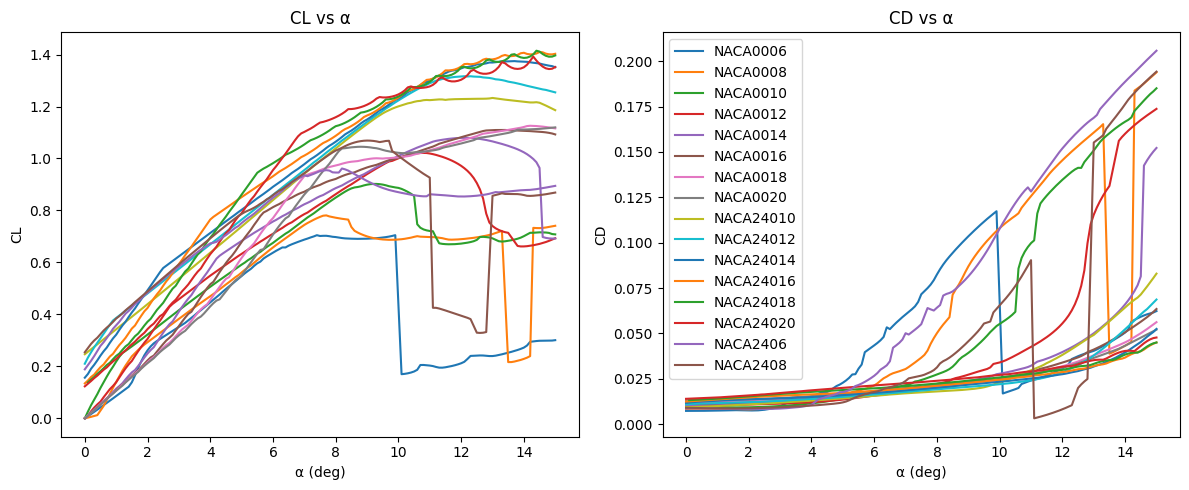

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for airfoil, grp in dg.groupby("airfoil"):
    s = grp.sort_values("alpha")
    axes[0].plot(s["alpha"], s["CL"], label=airfoil)
    axes[1].plot(s["alpha"], s["CD"], label=airfoil)

axes[0].set(title="CL vs α", xlabel="α (deg)", ylabel="CL")
axes[1].set(title="CD vs α", xlabel="α (deg)", ylabel="CD")

plt.tight_layout()
plt.legend()
plt.show()

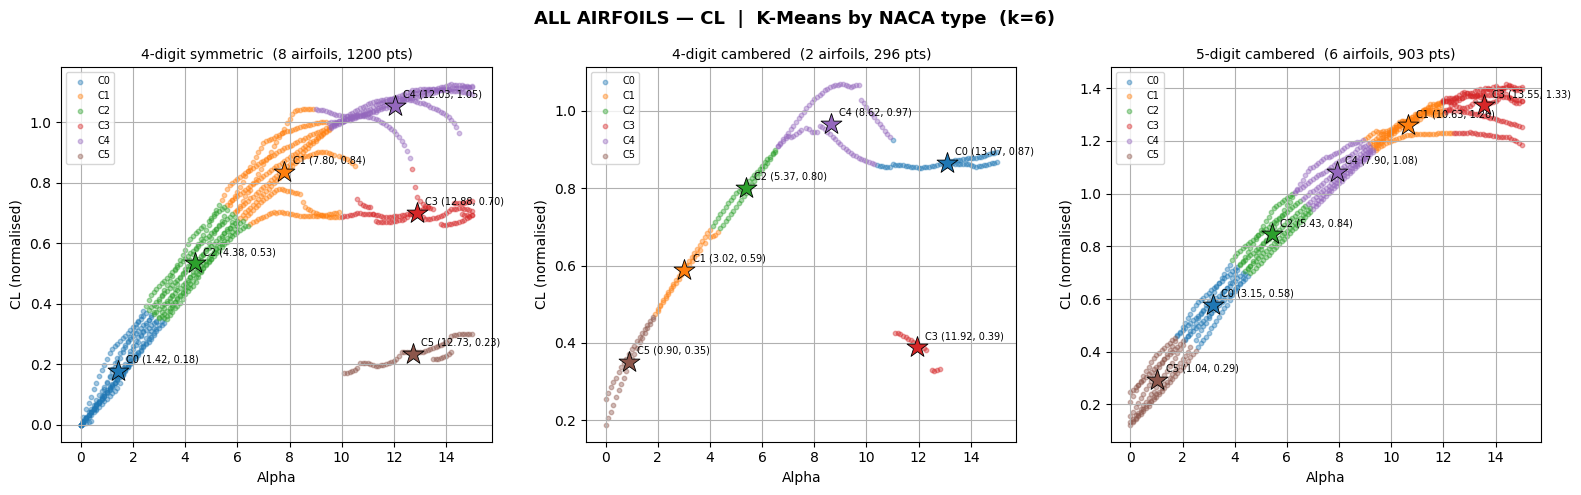

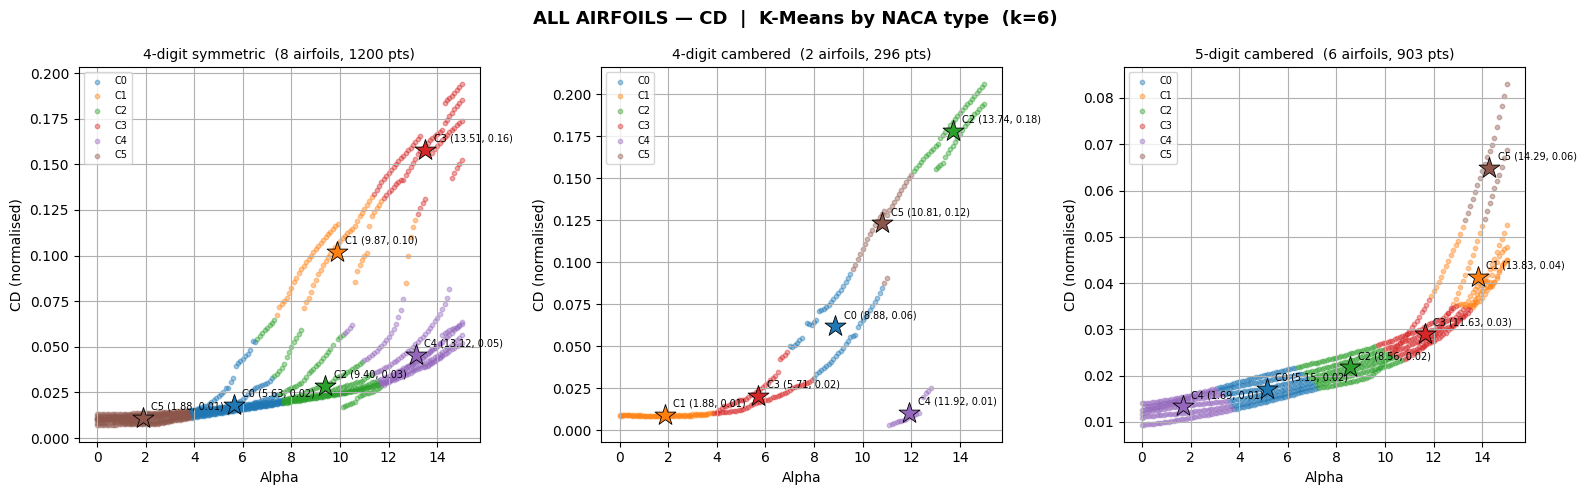

[CL] Original : 2324 rows  |  Removed : 75  |  Clean : 2324 rows
[CD] Original : 2382 rows  |  Removed : 17  |  Clean : 2382 rows


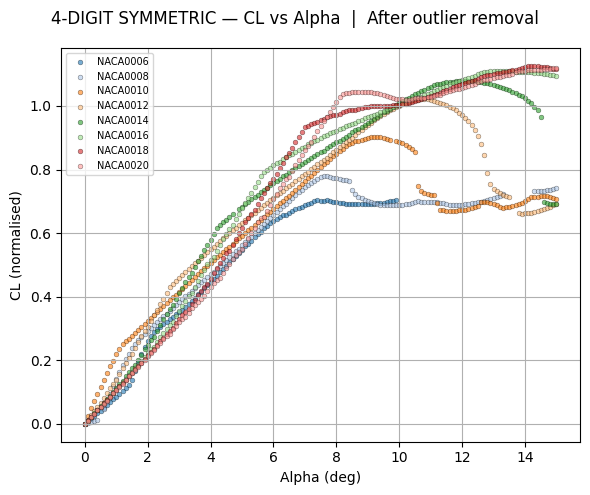

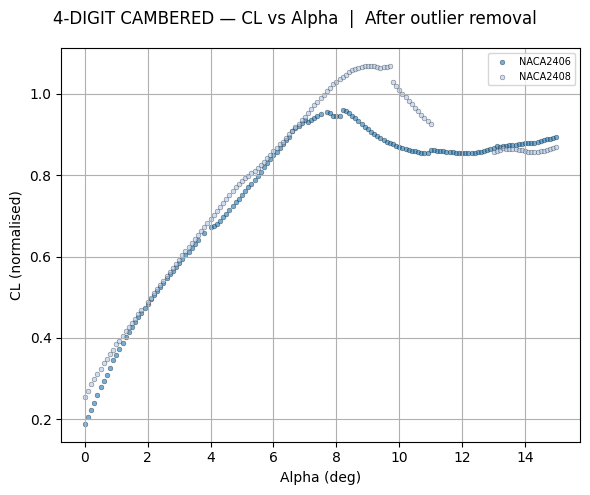

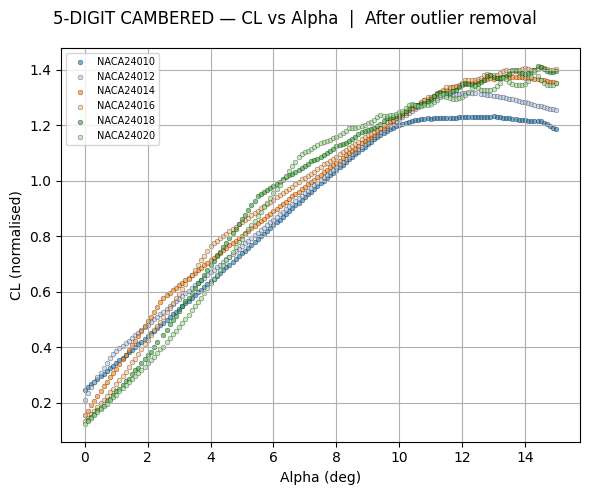

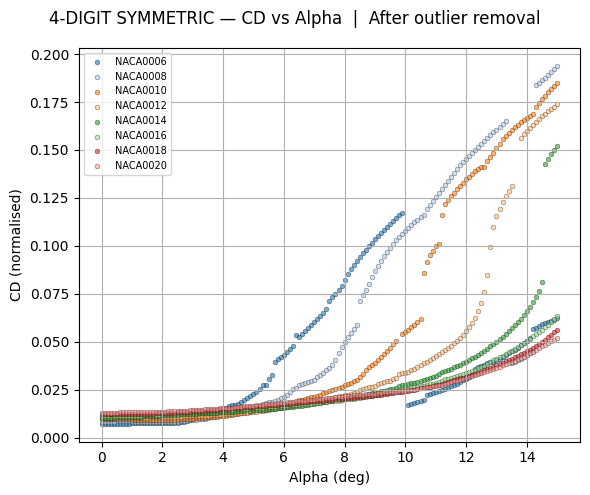

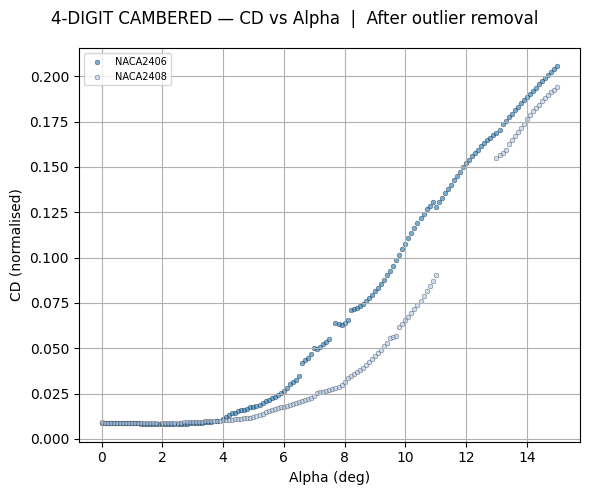

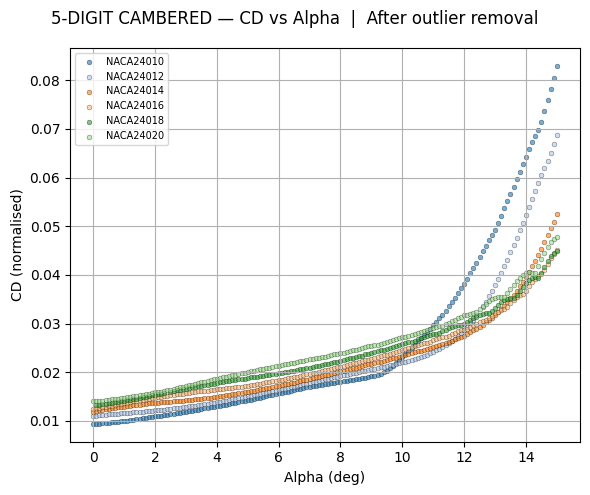

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import re
dg_spec = dg.copy()
dg_spec_3 = dg_spec.copy()
'''
# --- Min-Max normalisation of CL and CD to [0, 1] ---
for col in ["CL", "CD"]:
    col_min = dg[col].min()
    col_max = dg[col].max()
    dg[col] = (dg[col] - col_min) / (col_max - col_min)
'''
# --- NACA airfoil classification ---
def classify_naca(name):
    match = re.search(r'(\d{4,5})$', name.replace(" ", "").upper())
    if not match:
        return None
    digits = match.group(1)
    if len(digits) == 4:
        return '4-digit cambered' if int(digits[:2]) != 0 else '4-digit symmetric'
    elif len(digits) == 5:
        return '5-digit cambered'
    return None

dg_spec_3["naca_type"] = dg_spec_3["airfoil"].apply(classify_naca)
dg_spec_3 = dg_spec_3[dg_spec_3["naca_type"].notna()].reset_index(drop=True)

NACA_TYPES = [
    '4-digit symmetric',
    '4-digit cambered',
    '5-digit cambered',
]

# =============================================================================
# USER CONFIGURATION — define which clusters are outliers per NACA type
# Keys   : NACA type string (must match NACA_TYPES exactly)
# Values : list of cluster labels as strings "C0", "C1", …
#          Leave empty list [] to mark no clusters as outliers for that type
# =============================================================================
OUTLIER_CLUSTERS = {
    "CL": {
        '4-digit symmetric': ["C5"],
        '4-digit cambered' : ["C3"],
        '5-digit cambered' : [],
    },
    "CD": {
        '4-digit symmetric': [],
        '4-digit cambered' : ["C4"],
        '5-digit cambered' : [],
    },
}

def run_kmeans(subset, coeff_label, n_clusters):
    """Fit K-Means and return labels + centroids in original space."""
    data_array = subset[["alpha", coeff_label]].to_numpy()
    k          = min(n_clusters, len(data_array))
    scaler     = StandardScaler()
    D0         = scaler.fit_transform(data_array)
    kmeans     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels     = kmeans.fit_predict(D0)
    centroids  = scaler.inverse_transform(kmeans.cluster_centers_)
    return data_array, labels, centroids, k

def plot_clusters(coeff_label, n_clusters):
    """Figure 1 — raw K-Means clusters with centroids."""
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(
        f"ALL AIRFOILS — {coeff_label}  |  "
        f"K-Means by NACA type  (k={n_clusters})",
        fontweight="bold", fontsize=13
    )
    cmap = plt.get_cmap("tab10")

    for ax_idx, naca_type in enumerate(NACA_TYPES):
        ax     = axes[ax_idx]
        subset = dg_spec_3[dg_spec_3["naca_type"] == naca_type].copy()

        if subset.empty:
            ax.set_title(f"{naca_type} — no data")
            ax.axis("off")
            continue

        data_array, labels, centroids, k = run_kmeans(subset, coeff_label,
                                                       n_clusters)
        alpha = data_array[:, 0]
        y     = data_array[:, 1]

        for c in range(k):
            c_mask = labels == c
            ax.scatter(alpha[c_mask], y[c_mask],
                       s=10, alpha=0.4, color=cmap(c / 10),
                       label=f"C{c}")

        for c in range(k):
            cx, cy = centroids[c]
            ax.scatter(cx, cy, marker='*', s=250, zorder=5,
                       color=cmap(c / 10), edgecolors='k', linewidths=0.6)
            ax.annotate(f"C{c} ({cx:.2f}, {cy:.2f})",
                        (cx, cy), textcoords="offset points",
                        xytext=(6, 6), fontsize=7)

        n_airfoils = subset["airfoil"].nunique()
        ax.set_title(f"{naca_type}  ({n_airfoils} airfoils, "
                     f"{len(data_array)} pts)", fontsize=10)
        ax.set_xlabel("Alpha")
        ax.set_ylabel(f"{coeff_label} (normalised)")
        ax.legend(fontsize=7)
        ax.grid(True)

    plt.tight_layout()
    plt.show()

def get_clean_dg(coeff_label, n_clusters):
    """
    Run K-Means per NACA type, flag rows belonging to outlier clusters,
    and return a cleaned DataFrame with those rows removed.
    """
    outlier_indices = []

    for naca_type in NACA_TYPES:
        subset   = dg_spec_3[dg_spec_3["naca_type"] == naca_type].copy()
        if subset.empty:
            continue

        data_array, labels, centroids, k = run_kmeans(subset, coeff_label,
                                                       n_clusters)
        orig_idx = subset.index.to_numpy()

        # Convert "C0", "C3" etc. to integer indices
        flagged  = {int(c.replace("C", ""))
                    for c in OUTLIER_CLUSTERS[coeff_label].get(naca_type, [])}

        out_mask = np.array([labels[i] in flagged for i in range(len(labels))])
        outlier_indices.extend(orig_idx[out_mask].tolist())

    dg_spec_3_clean = dg_spec_3.drop(index=outlier_indices).reset_index(drop=True)
    print(f"[{coeff_label}] Original : {len(dg_spec_3_clean)} rows  |  "
          f"Removed : {len(outlier_indices)}  |  "
          f"Clean : {len(dg_spec_3_clean)} rows")
    return dg_spec_3_clean

def plot_airfoils_separately(dg_spec_3_clean, coeff_label):
    """
    Plot each NACA type in its own figure.
    Each airfoil gets its own color.
    """

    for naca_type in NACA_TYPES:

        subset = dg_spec_3_clean[dg_spec_3_clean["naca_type"] == naca_type]

        # One color per airfoil
        airfoils = sorted(subset["airfoil"].unique())
        cmap = plt.get_cmap("tab20")
        n_colors = len(airfoils)

        fig, ax = plt.subplots(figsize=(6, 5))
        fig.suptitle(
            f"{naca_type.upper()} — {coeff_label} vs Alpha  |  After outlier removal"
        )

        for i, airfoil in enumerate(airfoils):
            grp = subset[subset["airfoil"] == airfoil].sort_values("alpha")
            color = cmap(i % 20)  # wrap around if >20 airfoils

            ax.scatter(
                grp["alpha"],
                grp[coeff_label],
                s=12, alpha=0.6,
                color=color,
                edgecolors='k', linewidths=0.3,
                label=airfoil
            )

        ax.set_xlabel("Alpha (deg)")
        ax.set_ylabel(f"{coeff_label} (normalised)")
        ax.grid(True)
        ax.legend(fontsize=7, markerscale=1, frameon=True)
        plt.tight_layout()
        plt.show()


# --- Step 1: inspect clusters ---
plot_clusters("CL", n_clusters=6)
plot_clusters("CD", n_clusters=6)

# --- Step 2: remove outlier clusters + plot clean data ---
dg_spec_3_clean_cl = get_clean_dg("CL", n_clusters=6)
dg_spec_3_clean_cd = get_clean_dg("CD", n_clusters=6)

plot_airfoils_separately(dg_spec_3_clean_cl, "CL")
plot_airfoils_separately(dg_spec_3_clean_cd, "CD")

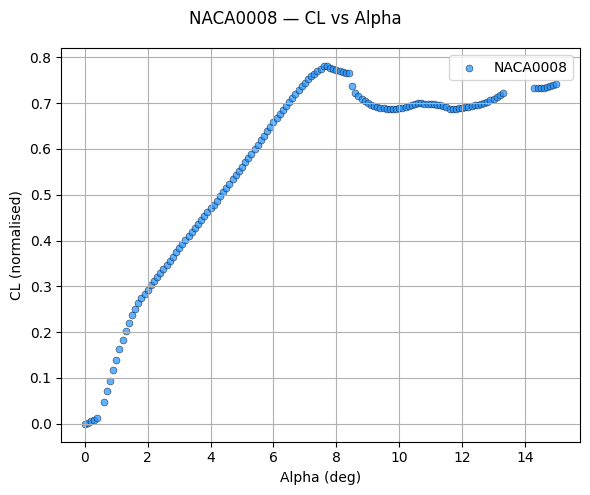

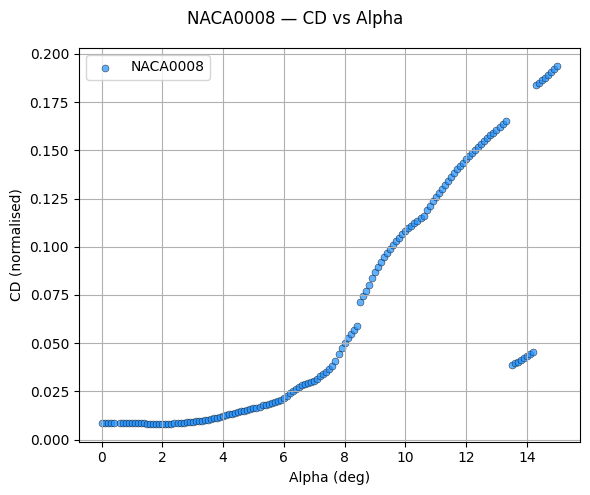

In [22]:
def plot_single_airfoil(dg_clean, airfoil_name, coeff_label):
    """
    Plot one specific airfoil (e.g., NACA0006) in its own figure.
    """
    subset = dg_clean[dg_clean["airfoil"] == airfoil_name].copy()

    if subset.empty:
        print(f"No data found for {airfoil_name}")
        return

    subset = subset.sort_values("alpha")

    fig, ax = plt.subplots(figsize=(6, 5))
    fig.suptitle(f"{airfoil_name} — {coeff_label} vs Alpha")

    ax.scatter(
        subset["alpha"],
        subset[coeff_label],
        s=25, alpha=0.7,
        color="dodgerblue",
        edgecolors="k", linewidths=0.4,
        label=airfoil_name
    )

    ax.set_xlabel("Alpha (deg)")
    ax.set_ylabel(f"{coeff_label} (normalised)")
    ax.grid(True)
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_single_airfoil(dg_spec_3_clean_cl, "NACA0008", "CL")
plot_single_airfoil(dg_spec_3_clean_cd, "NACA0008", "CD")



In [23]:
dg_spec_3_clean_cl = dg_spec_3_clean_cl[~((dg_spec_3_clean_cl["airfoil"] == "NACA0006") &
                            (dg_spec_3_clean_cl["alpha"] > 8))].reset_index(drop=True)

dg_spec_3_clean_cd = dg_spec_3_clean_cd[~((dg_spec_3_clean_cd["airfoil"] == "NACA0006") &
                            (dg_spec_3_clean_cd["alpha"] > 8))].reset_index(drop=True)

dg_spec_3_clean_cl = dg_spec_3_clean_cl[~((dg_spec_3_clean_cl["airfoil"] == "NACA0008") &
                            (dg_spec_3_clean_cl["alpha"] > 13.4) & (dg_spec_3_clean_cl["alpha"] < 14.5))].reset_index(drop=True)

dg_spec_3_clean_cd = dg_spec_3_clean_cd[~((dg_spec_3_clean_cd["airfoil"] == "NACA0008") &
                            (dg_spec_3_clean_cd["alpha"] > 13.4) & (dg_spec_3_clean_cd["alpha"] < 14.5))].reset_index(drop=True)


In [24]:
dg_pca = dg_spec_3_clean_cl.copy()              # does not change if put cl or cd
dg_pca = dg_pca.drop(["naca_type"], axis=1)
print(dg_pca)

# import pandas as pd
# from google.colab import files

# dg_pca.to_csv('outlier_removed_data.csv', index=False)

# files.download('outlier_removed_data.csv')


       airfoil  alpha      CL       CD
0     NACA0006    0.0  0.0000  0.00732
1     NACA0006    0.1  0.0082  0.00732
2     NACA0006    0.2  0.0165  0.00733
3     NACA0006    0.3  0.0249  0.00734
4     NACA0006    0.4  0.0333  0.00735
...        ...    ...     ...      ...
2298  NACA2408   14.6  0.8606  0.18784
2299  NACA2408   14.7  0.8624  0.18950
2300  NACA2408   14.8  0.8644  0.19110
2301  NACA2408   14.9  0.8665  0.19268
2302  NACA2408   15.0  0.8688  0.19423

[2303 rows x 4 columns]


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


In [152]:
# Normalise column names
df = dg_pca.copy()
df.columns = df.columns.str.strip().str.upper()
df = df.rename(columns={"AIRFOIL": "airfoil", "ALPHA": "alpha", "CL": "CL", "CD": "CD"})
df = df.dropna().drop_duplicates()
df["alpha"] = df["alpha"].round(2)
# print(df[100:150])
print(df)

# filter dfand filter ofr only the airfoils you want to keep.
def filter_airfoils(df, keep_list):
    """
    Keep only the airfoils listed in keep_list.
    All other airfoils are removed from the dataframe.
    """
    keep_list = [a.strip().upper() for a in keep_list]   # normalize names
    df2 = df[df["airfoil"].str.upper().isin(keep_list)].copy()

    if df2.empty:
        print("Warning: no matching airfoils found. Check names.")
    return df2

# --- NEW: filter airfoils ---
# airfoils_to_keep = ["NACA0012", "NACA0014"]
# airfoils_to_keep = ["NACA0006", "NACA0008", "NACA0010", "NACA0012", "NACA0014", "NACA0016", "NACA0018", "NACA0020", "NACA24010", "NACA24012", "NACA24014", "NACA24016", "NACA24018", "NACA24020", "NACA2406", "NACA2408"]

# airfoils_to_keep = ["NACA0006", "NACA0008", "NACA0010", "NACA0012", "NACA0014", "NACA0016", "NACA0018", "NACA0020"]
airfoils_to_keep = ["NACA24010", "NACA24012", "NACA24014", "NACA24016", "NACA24018", "NACA24020", "NACA2406", "NACA2408"]


df_filtered = df[df["airfoil"].isin(airfoils_to_keep)].copy()



# noramlise the data

       airfoil  alpha      CL       CD
0     NACA0006    0.0  0.0000  0.00732
1     NACA0006    0.1  0.0082  0.00732
2     NACA0006    0.2  0.0165  0.00733
3     NACA0006    0.3  0.0249  0.00734
4     NACA0006    0.4  0.0333  0.00735
...        ...    ...     ...      ...
2298  NACA2408   14.6  0.8606  0.18784
2299  NACA2408   14.7  0.8624  0.18950
2300  NACA2408   14.8  0.8644  0.19110
2301  NACA2408   14.9  0.8665  0.19268
2302  NACA2408   15.0  0.8688  0.19423

[2303 rows x 4 columns]


In [149]:
def naca_parameters(naca_str):
    code = naca_str.upper().replace("NACA", "").strip()

    if len(code) == 5:
        max_camber      = int(code[0]) / 100   #devide by 100 to not have a percentage
        camber_position = int(code[1]) / 20    # position is a tenth of the chord
        thickness       = int(code[3:]) / 100

    if not code.isdigit():
        raise ValueError(f"Expected a 4 or 5 digit NACA code, got: '{naca_str}'")

    if len(code) == 4:
        max_camber      = int(code[0]) / 100   #devide by 100 to not have a percentage
        camber_position = int(code[1]) / 10    # position is a tenth of the chord
        thickness       = int(code[2:]) / 100

    return {"thickness": thickness, "max_camber": max_camber, "max_camber_position": camber_position}


In [153]:
# ==========================================================
# --- Extract NACA geometric parameters ---
def extract_features(row):
      params = naca_parameters(row["airfoil"])
      return pd.Series([params["thickness"], params["max_camber"], params["max_camber_position"]])

df_filtered[["thickness", "camber", "x_c"]] = df_filtered.apply(extract_features, axis=1)

# Convert everything to numeric and clean
df_encoded = df_filtered.drop(columns=["airfoil"])
df_encoded = df_encoded.apply(pd.to_numeric, errors="coerce").dropna()

# Keep track of surviving rows
surviving_index = df_encoded.index

X = df_encoded.to_numpy()
feature_names = df_encoded.columns.tolist()

# plt.plot(df_encoded.iloc[:, 0], df_encoded.iloc[:, 1], 'o')
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Standardize X
scaler = StandardScaler()
X_std = scaler.fit_transform(X)           # !!!

# 2. Fit PCA
pca = PCA(n_components=6)
Z = pca.fit_transform(X_std)
A = pca.components_.T
L = pca.explained_variance_

mu = scaler.mean_
sigma = scaler.scale_

In [108]:
def predict_polar_v2(
    new_geometry: dict,
    Z, A, mu, sigma,
    df_ref, df_encoded, feat_names,
    n_neighbors: int = 10,
    alpha_range: tuple = (0, 15),
    alpha_step: float = 0.1,
    geom_weight: float = 0.7,
    alpha_weight: float = 0.3
):
    """
    Predict CL(alpha) and CD(alpha) using PCA-space weighted interpolation.

    Geometry distance uses only:
        - thickness (t/c)
        - camber (m/c)
        - camber position (p/c)

    Parameters
    ----------
    new_geometry : dict
        {"thickness": t/c, "max_camber": m/c, "max_camber_position": p/c}

    Z, A, mu, sigma : PCA outputs
    df_ref          : reference dataframe (unused but kept for compatibility)
    df_encoded      : numeric dataframe used for PCA
    feat_names      : list of feature names
    n_neighbors     : number of nearest neighbours
    alpha_range     : (min_alpha, max_alpha)
    alpha_step      : resolution of alpha grid
    geom_weight     : weight of geometry distance
    alpha_weight    : weight of alpha proximity

    Returns
    -------
    alpha_grid : ndarray
    CL_pred    : ndarray
    CD_pred    : ndarray
    """

    # ------------------------------------------------------
    # Feature indices
    # ------------------------------------------------------
    geo_cols = ["thickness", "camber", "x_c"]
    aero_cols = ["alpha", "CL", "CD"]

    missing = [f for f in geo_cols + aero_cols if f not in feat_names]
    if missing:
        raise ValueError(f"Missing required features: {missing}")

    geo_idx = [feat_names.index(f) for f in geo_cols]
    alpha_idx = feat_names.index("alpha")
    CL_idx    = feat_names.index("CL")
    CD_idx    = feat_names.index("CD")

    # ------------------------------------------------------
    # Standardize geometry of query airfoil
    # ------------------------------------------------------
    geo_vec = np.array([
        new_geometry["thickness"],
        new_geometry["max_camber"],
        new_geometry["max_camber_position"]
    ])

    geo_vec_std = (geo_vec - mu[geo_idx]) / sigma[geo_idx]

    # ------------------------------------------------------
    # Standardize dataset geometry
    # ------------------------------------------------------
    X_all = df_encoded.to_numpy(dtype=float)
    X_geo_std = (X_all[:, geo_idx] - mu[geo_idx]) / sigma[geo_idx]

    # Geometry distance (3D Euclidean)
    geo_dist = np.linalg.norm(X_geo_std - geo_vec_std, axis=1)

    # ------------------------------------------------------
    # Prepare alpha grid
    # ------------------------------------------------------
    alpha_grid = np.arange(alpha_range[0], alpha_range[1], alpha_step)
    CL_pred = np.zeros_like(alpha_grid)
    CD_pred = np.zeros_like(alpha_grid)

    # Precompute standardized alpha column
    alpha_all_std = (X_all[:, alpha_idx] - mu[alpha_idx]) / sigma[alpha_idx]

    # ------------------------------------------------------
    # Loop over alpha queries
    # ------------------------------------------------------
    for i, alpha_q in enumerate(alpha_grid):

        alpha_q_std = (alpha_q - mu[alpha_idx]) / sigma[alpha_idx]
        alpha_dist = np.abs(alpha_all_std - alpha_q_std)

        # Combined distance metric
        dist = geom_weight * geo_dist + alpha_weight * alpha_dist

        # Nearest neighbours
        nn_idx = np.argsort(dist)[:n_neighbors]
        nn_dist = dist[nn_idx]

        # Inverse-distance weights
        w = 1.0 / (nn_dist + 1e-8)
        w /= w.sum()

        # Blend PCA scores
        Z_blend = np.average(Z[nn_idx], axis=0, weights=w)

        # Reconstruct full feature vector
        X_rec = (Z_blend @ A.T) * sigma + mu

        CL_pred[i] = X_rec[CL_idx]
        CD_pred[i] = X_rec[CD_idx]

    # ------------------------------------------------------
    # Smoothing
    # ------------------------------------------------------
    def smooth(arr, w=2):
        return np.convolve(arr, np.ones(w)/w, mode="same")

    CL_pred = smooth(CL_pred)
    CD_pred = smooth(np.abs(CD_pred))

    return alpha_grid, CL_pred, CD_pred



In [120]:
def plot_predicted_polar(
    airfoil_label,
    alpha_grid, CL_pred, CD_pred,
    df_ref=None,
    ref_airfoils=None,
    reel_data=None
):
    """
    Plot predicted CL(alpha), CD(alpha), and optionally overlay reference curves.

    Parameters
    ----------
    airfoil_label : str
    alpha_grid    : ndarray
    CL_pred       : ndarray
    CD_pred       : ndarray
    df_ref        : dataframe with columns ["airfoil","alpha","CL","CD"]
    ref_airfoils  : list of airfoil names to overlay
    reel_data     : dict with keys {"alpha","CL","CD"} for real measurements
    """

    fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=100)
    axes[0].legend(fontsize=8, bbox_to_anchor=(1.05, 1), loc="upper left")
    axes[1].legend(fontsize=8, bbox_to_anchor=(1.05, 1), loc="upper left")

    # ------------------------------------------------------
    # Predicted curves
    # ------------------------------------------------------
    axes[0].plot(alpha_grid, CL_pred, "b-", lw=2.5, label=f"Predicted {airfoil_label}")
    axes[1].plot(alpha_grid, CD_pred, "b-", lw=2.5, label=f"Predicted {airfoil_label}")

    # ------------------------------------------------------
    # Reference airfoils
    # ------------------------------------------------------
    if df_ref is not None and ref_airfoils is not None:
        colors = ["r", "g", "m", "c", "b", "k", "y"]
        for airfoil, col in zip(ref_airfoils, colors):
            df_r = df_ref[df_ref["airfoil"] == airfoil].sort_values("alpha")
            axes[0].plot(df_r["alpha"], df_r["CL"], f"{col}--", lw=1.5, alpha=0.7, label=f"{airfoil} ref")
            axes[1].plot(df_r["alpha"], df_r["CD"], f"{col}--", lw=1.5, alpha=0.7, label=f"{airfoil} ref")

    # ------------------------------------------------------
    # Real measurement overlay
    # ------------------------------------------------------
    if reel_data is not None:
        axes[0].plot(reel_data["alpha"], reel_data["CL"], "k--", lw=1.5, alpha=0.7, label="Real CL")
        axes[1].plot(reel_data["alpha"], reel_data["CD"], "k--", lw=1.5, alpha=0.7, label="Real CD")

    # ------------------------------------------------------
    # Formatting
    # ------------------------------------------------------
    axes[0].set(xlabel="α (deg)", ylabel="CL", title="Lift Curve")
    axes[1].set(xlabel="α (deg)", ylabel="CD", title="Drag Curve")

    for ax in axes:
        ax.axhline(0, color="k", lw=0.5, ls="--")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)

    fig.suptitle(f"PCA Polar Prediction — {airfoil_label} with 4PC", fontsize=14)
    plt.tight_layout()
    plt.show()


/tmp/ipykernel_10515/3204650346.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend(fontsize=8, bbox_to_anchor=(1.05, 1), loc="upper left")
/tmp/ipykernel_10515/3204650346.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend(fontsize=8, bbox_to_anchor=(1.05, 1), loc="upper left")


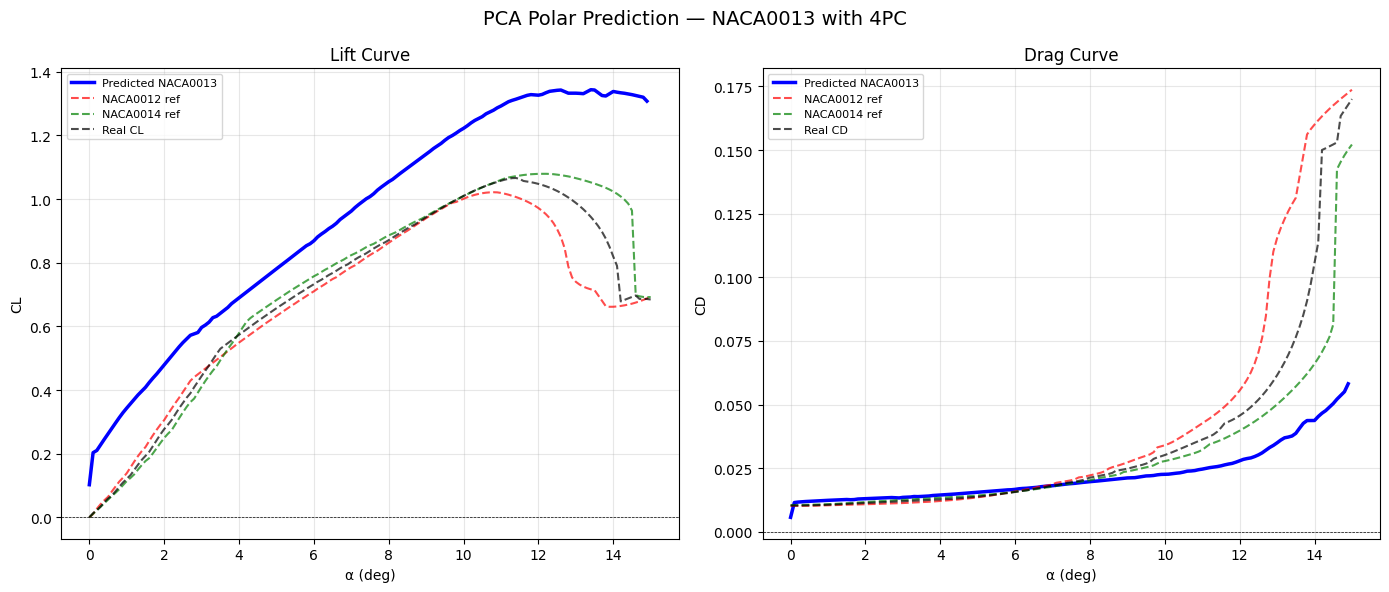

In [154]:
# ---- Example 1: NACA 4412-like geometry ----

# MODEL WITH PCA
geom_0010 = {
    "thickness":              0.13,
    "max_camber":             0,
    "max_camber_position":    0,
}

alpha_pred, CL_pred, CD_pred = predict_polar_v2(
    new_geometry = geom_0010,
    Z=Z, A=A, mu=mu, sigma=sigma,
    df_ref=df_filtered,          # <--- filtered
    df_encoded=df_encoded,       # <--- filtered
    feat_names=df_encoded.columns.tolist(),
    n_neighbors=5,
)


reel_df = pd.read_csv("merged_airfoil_data_0013.csv")

reel_data = {
    "alpha": reel_df["alpha"].to_numpy(),
    "CL":    reel_df["CL"].to_numpy(),
    "CD":    reel_df["CD"].to_numpy(),
}

plot_predicted_polar(
    airfoil_label = "NACA0013",
    alpha_grid    = alpha_pred,
    CL_pred       = CL_pred,
    CD_pred       = CD_pred,
    df_ref        = df,
    ref_airfoils  = ["NACA0012", "NACA0014"],
    reel_data     = reel_data
)
